In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
font1 = {'weight': 'bold', 'size': 18}

In [21]:
df_ne = pd.read_csv('LMP_DISPATCH_121_NUCLEAR_1.csv')
df_load = pd.read_csv('Real_Time_load_hourly.csv')

total_load = df_load['1'] + df_load['2'] + df_load['3']
tot_load = total_load.to_numpy()

# set the LMP >= 100 to 100 (for visualization)
df_ne[df_ne['LMP']>=100] = 100

## Simple Price-Load Relationship

In [50]:
# fig, ax = plt.subplots(figsize=(16,12))
# ax.plot(tot_load)
# ax.set_ylim(0, 8000)
# ax2 = ax.twinx()
# ax2.plot(df_ne['LMP'], c='r')

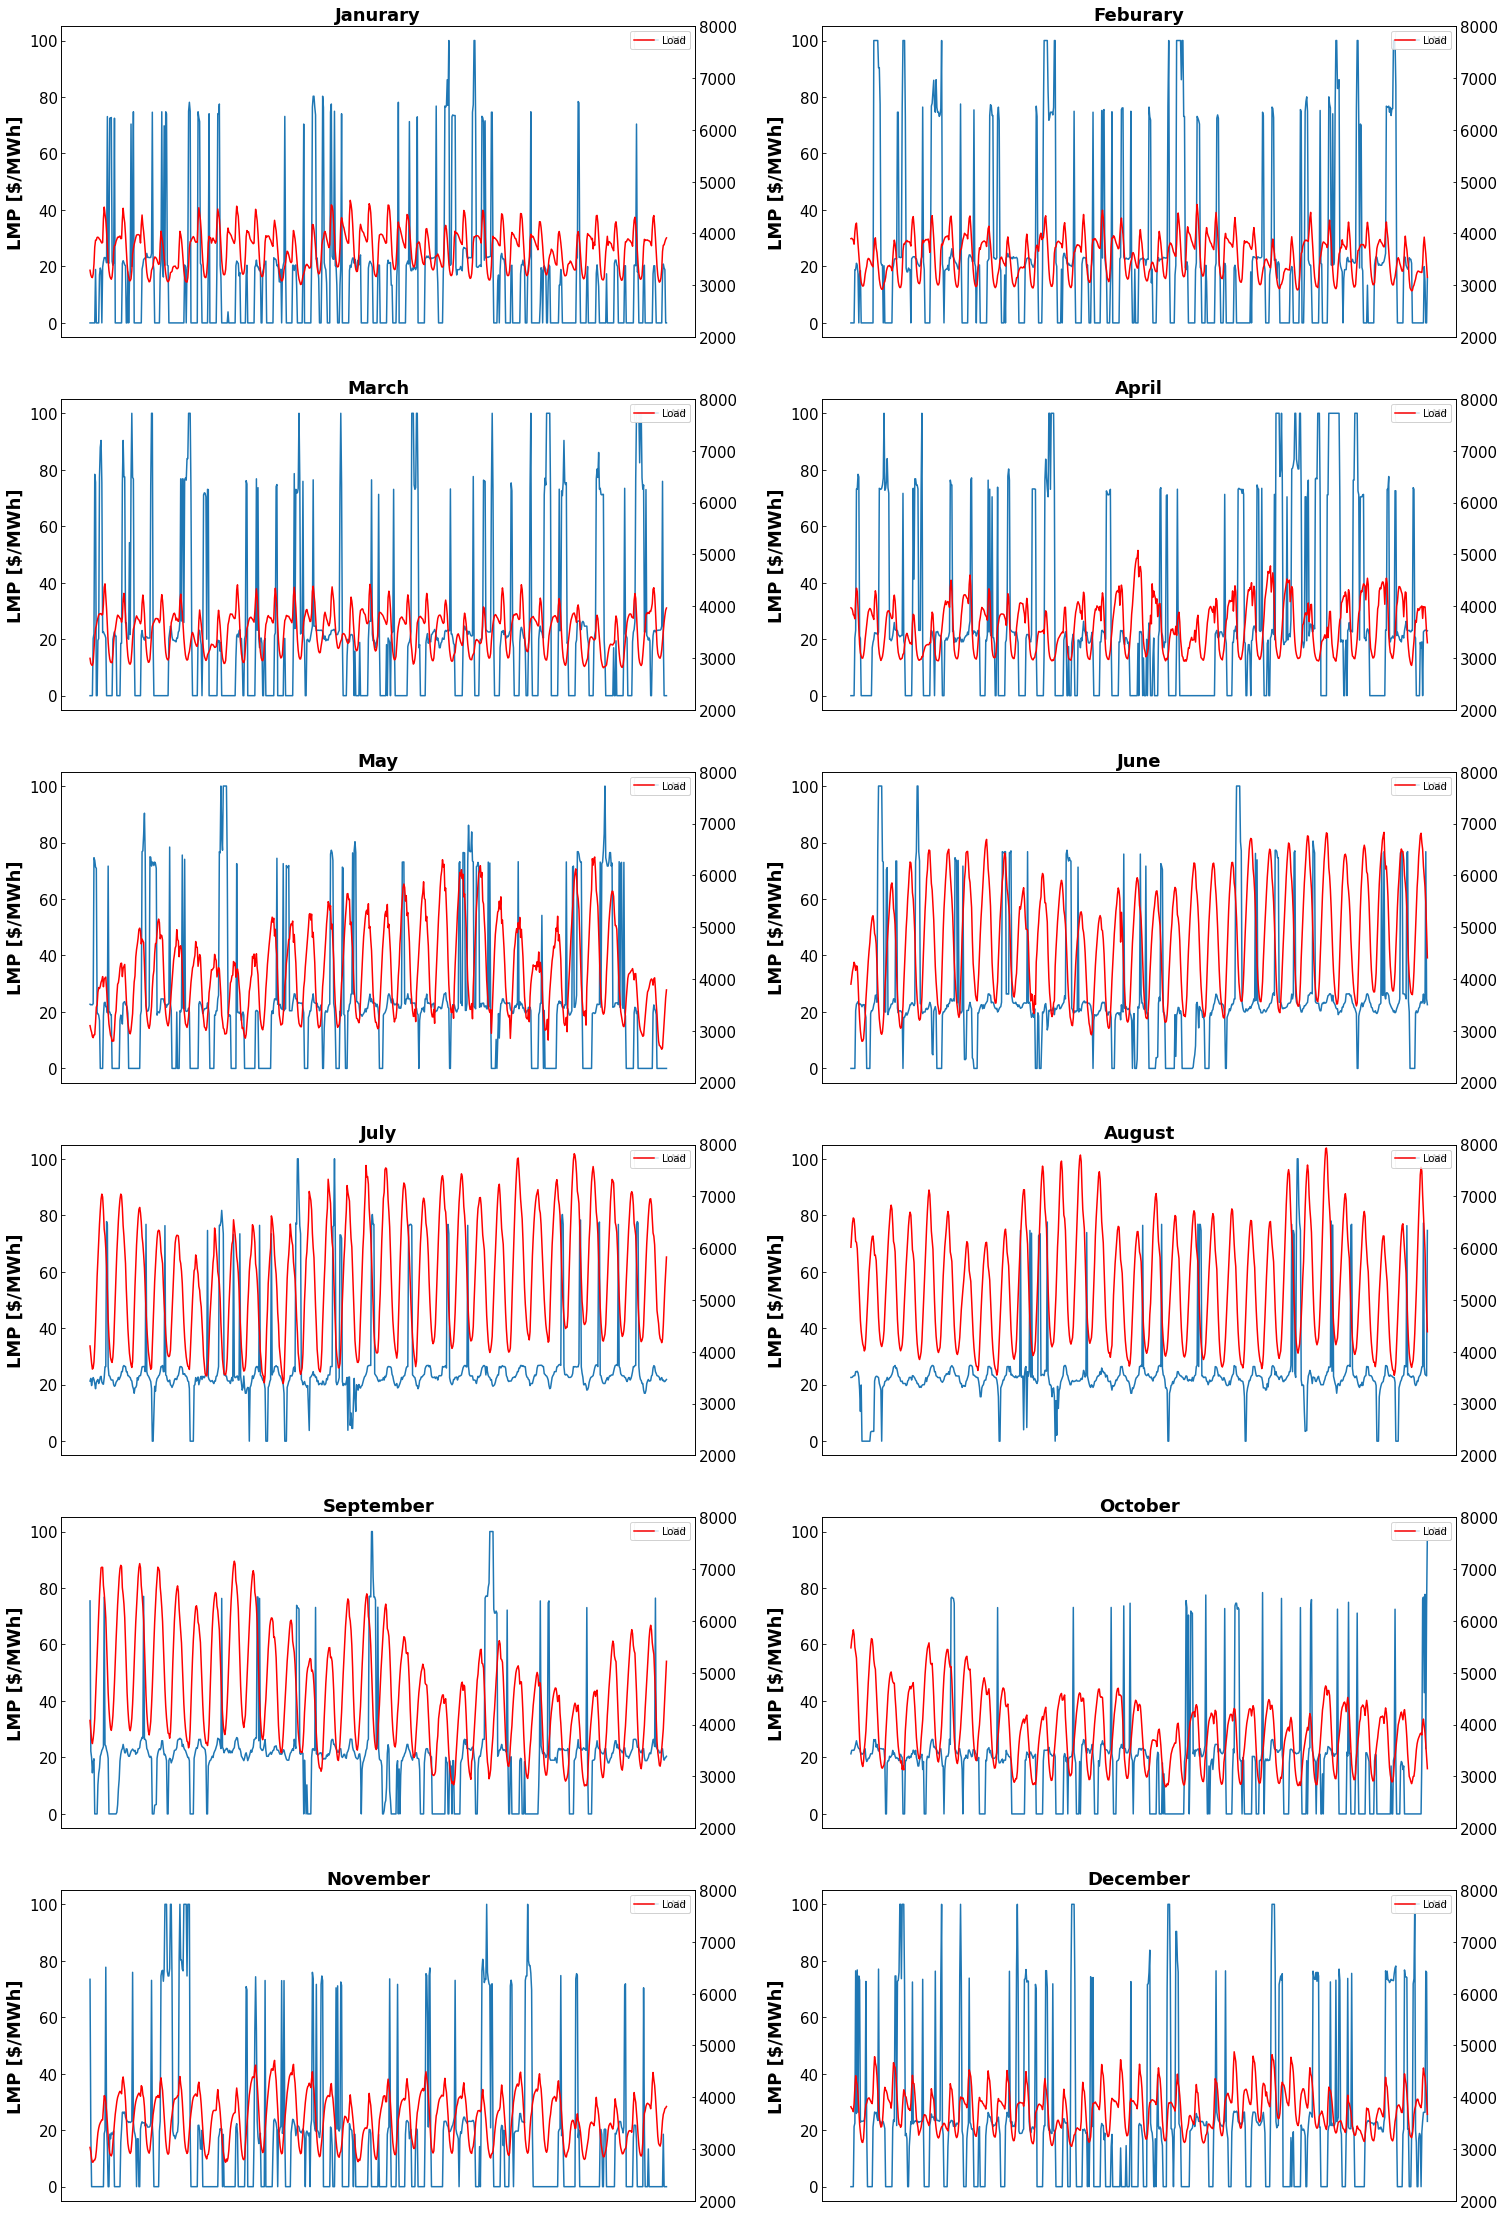

In [71]:
# Line plot
fig, axs = plt.subplots(6,2, figsize=(25, 40))
Month = ['Janurary', 'Feburary', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
c = 0

for i in range(6):
    for j in range(2):
        axs[i, j].tick_params(direction='in', top=True, right=True, labelsize = 15)
        axs[i, j].set_xticks([])
        axs[i, j].set_ylabel('LMP [$/MWh]', font=font1)
        axs[i, j].set_title(Month[c*2+j], font=font1)
        axs[i, j].plot(df_ne['LMP'][int(len(df_ne['LMP'].index)*(2*c+j)/12):int(len(df_ne['LMP'].index)*(2*c+(1+j))/12)], label='LMP')
        axs2 = axs[i, j].twinx()
        axs2.tick_params(direction='in', top=True, right=True, labelsize = 15)
        axs2.plot(total_load[int(len(total_load.index)*(2*c+j)/12):int(len(total_load.index)*(2*c+(1+j))/12)], c='r', label='Load')
        axs2.set_ylim(2000, 8000)
        #         axs2.set_ylabel('Capacity Factor', font=font1)
#         axs2.tick_params(direction='in', top=True, right=True, labelsize = 15)
        axs[i,j].legend(loc='upper right')
        axs2.legend(loc='upper right')
    c += 1


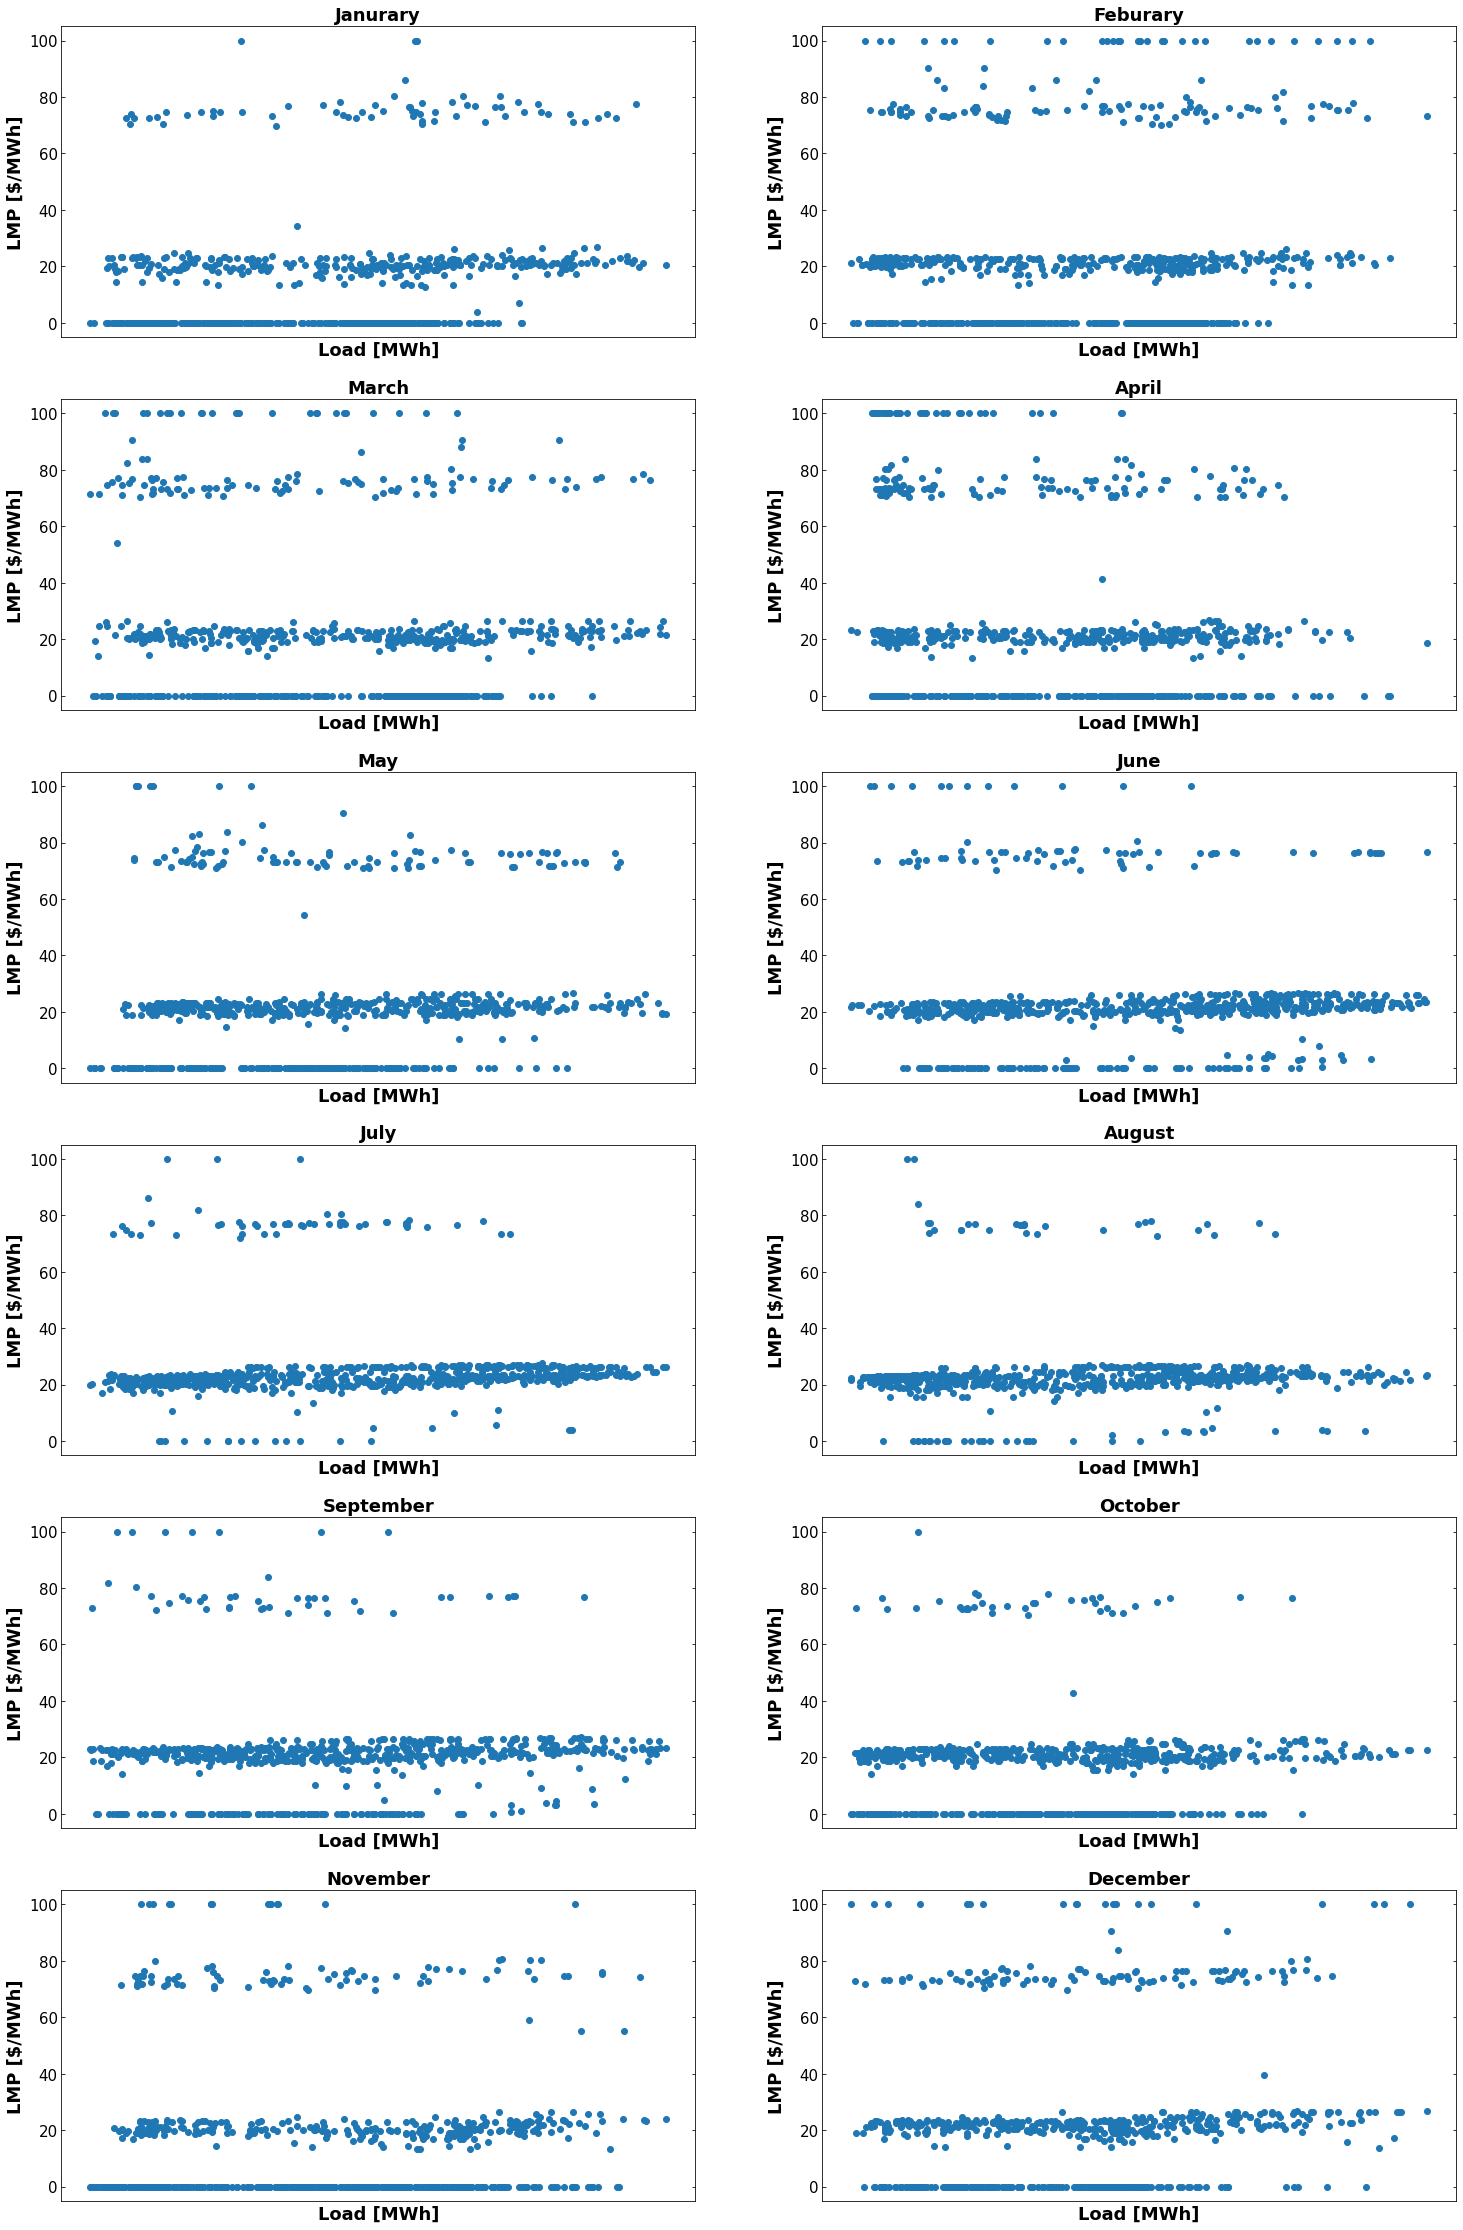

In [46]:
# Line plot
fig, axs = plt.subplots(6,2, figsize=(25, 40))
Month = ['Janurary', 'Feburary', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
c = 0

for i in range(6):
    for j in range(2):
        axs[i, j].tick_params(direction='in', top=True, right=True, labelsize = 15)
        axs[i, j].set_xticks([])
        axs[i, j].set_ylabel('LMP [$/MWh]', font=font1)
        axs[i, j].set_title(Month[c*2+j], font=font1)
        axs[i, j].scatter(total_load[int(len(total_load.index)*(2*c+j)/12):int(len(total_load.index)*(2*c+(1+j))/12)], df_ne['LMP'][int(len(df_ne['LMP'].index)*(2*c+j)/12):int(len(df_ne['LMP'].index)*(2*c+(1+j))/12)])
        axs[i, j].set_xlabel('Load [MWh]', font=font1)
    c += 1


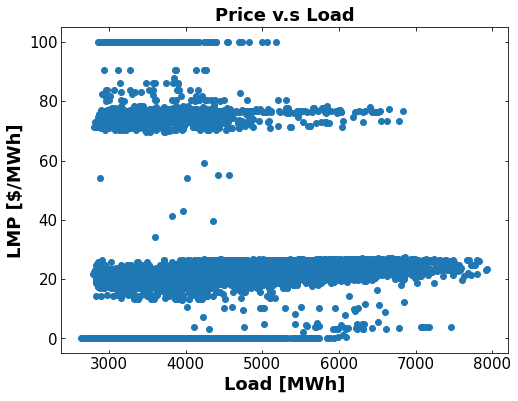

In [49]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.tick_params(direction='in', top=True, right=True, labelsize = 15)
ax.scatter(tot_load, df_ne["LMP"].to_numpy())
ax.set_ylabel('LMP [$/MWh]', font=font1)
ax.set_xlabel('Load [MWh]', font=font1)
ax.set_title('Price v.s Load', font=font1)
plt.show()

## Consider Renewables

### Plot total-load - renewable vs price 

In [51]:
df_wind = pd.read_csv('Real_Time_wind_hourly.csv')
df_pv = pd.read_csv('Real_Time_pv_hourly.csv')
df_rtpv = pd.read_csv('Real_Time_rtpv_hourly.csv')
df_hydro = pd.read_csv('Real_Time_hydro_hourly.csv')
df_csp = pd.read_csv('Real_Time_csp_hourly.csv')

# extract every generator unit data
def sum_single_renewable(df):
    re_sum_all = []
    for index, row in df.iterrows():
        re_sum = 0
        re_sum = row[df.columns[5:]].sum()
        re_sum_all.append(re_sum)
    
    return re_sum_all

wind_sum_all = sum_single_renewable(df_wind)
pv_sum_all = sum_single_renewable(df_pv)
rtpv_sum_all = sum_single_renewable(df_rtpv)
hydro_sum_all = sum_single_renewable(df_hydro)
csp_sum_all = sum_single_renewable(df_csp)

renew_sum_all = np.array(wind_sum_all) + np.array(pv_sum_all) + np.array(rtpv_sum_all) + np.array(hydro_sum_all) + np.array(csp_sum_all)
renew_sum_all

array([2637.5  , 2620.44 , 2584.862, ...,  560.562,  522.762,  564.602])

In [68]:
dispatable_unit_load = tot_load - renew_sum_all
df = pd.DataFrame({
    'Dispatch Load': dispatable_unit_load,
    'LMP': df_ne["LMP"].to_numpy()
})

df[(df['Dispatch Load'] >= 0) & (df['LMP'] == 0.0)]

df

,Dispatch Load,LMP
0,652.030156,0.000000
1,577.419856,0.000000
2,573.841060,0.000000
3,661.401413,0.000000
4,641.440182,0.000000
...,...,...
8779,3914.497997,26.324557
8780,3888.780274,26.324557
8781,3656.666558,76.324557
8782,3429.247378,75.908700


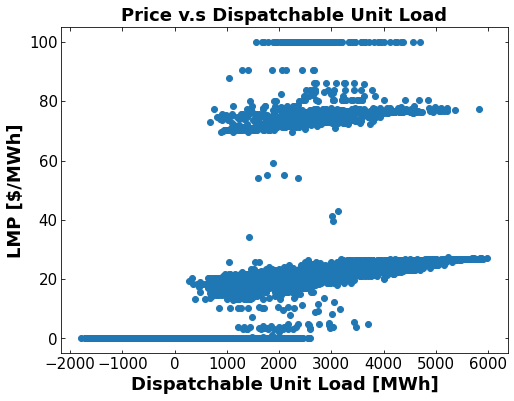

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.tick_params(direction='in', top=True, right=True, labelsize = 15)
ax.scatter(dispatable_unit_load, df_ne["LMP"].to_numpy())
ax.set_ylabel('LMP [$/MWh]', font=font1)
ax.set_xlabel('Dispatchable Unit Load [MWh]', font=font1)
ax.set_title('Price v.s Dispatchable Unit Load', font=font1)
plt.show()

In [80]:
from idaes.apps.grid_integration.utils import convert_marginal_costs_to_actual_costs
from egret.model_library.transmission import tx_utils

In [84]:
bids = [(30, 14.19), (45.33, 14.19), (60.67, 16.97), (76, 18.07)]
cost_paris = convert_marginal_costs_to_actual_costs(bids)
temp_curve = {
    "data_type": "cost_curve",
    "cost_curve_type": "piecewise",
    "values": cost_paris,
}
tx_utils.validate_and_clean_cost_curve(curve=temp_curve, curve_type="cost_curve", p_min=30, p_max=76, gen_name='103_STEAM_3', t=0)

[(30, 425.7), (45.33, 643.2327), (60.67, 903.5525), (76, 1180.5656)]